# Case Study 2: Purple Martin Migration Analysis

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString

## 2. Load Purple Martin GPS Dataset

In [2]:
birds_df=pd.read_csv(r"C:\Data Analytics\GeoSpatialAnalysis\Data\purple_martin.csv")

## Creating a GeoDataFrame

The latitude and longitude coordinates were converted into Point geometries and stored in a GeoDataFrame using the EPSG:4326 coordinate reference system.

In [3]:
birds = gpd.GeoDataFrame(
    birds_df,
    geometry=gpd.points_from_xy(
        birds_df["location-long"],
        birds_df["location-lat"]
    ),
    crs="EPSG:4326"
)

## Visualizing Bird Locations Across the Americas

In [4]:
import geodatasets
world=gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")

<Axes: >

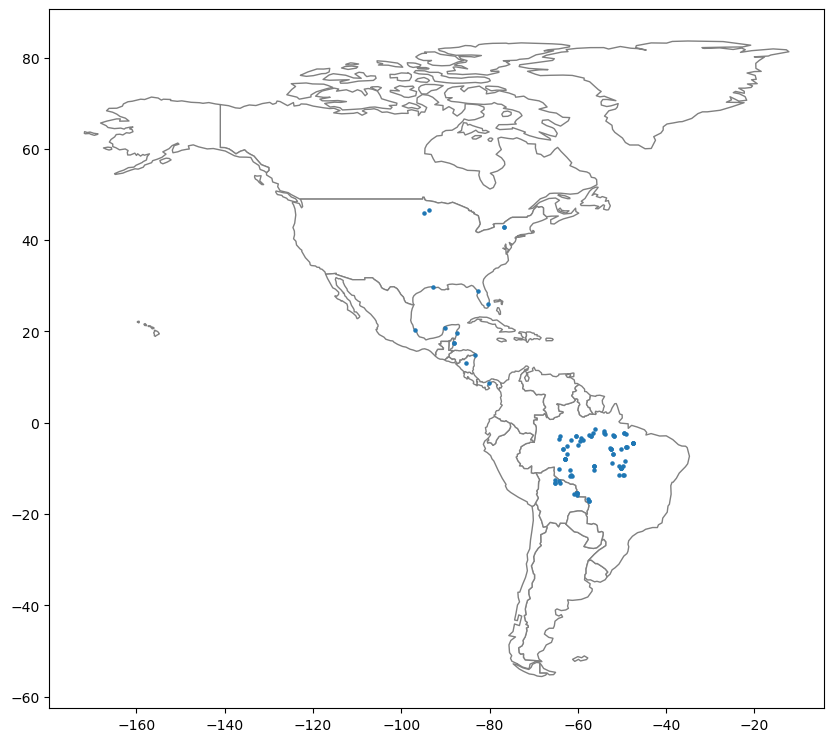

In [5]:
americas = world.loc[
    world['CONTINENT'].isin(['North America', 'South America'])
]

ax = americas.plot(
    figsize=(10,10),
    color='white',
    edgecolor='gray'
)

birds.plot(ax=ax, markersize=5)

In [6]:
fig = ax.get_figure()

fig.savefig(
    r"C:\Data Analytics\GeoSpatialAnalysis\Images\CaseStudy2\bird_locations_americas.png",
    dpi=300,
    bbox_inches="tight"
)

## Creating Migration Routes

In [7]:
path_df=birds.groupby('tag-local-identifier')['geometry'].apply(list).apply(lambda x: LineString(x)).reset_index()
path_gdf=gpd.GeoDataFrame(path_df,geometry=path_df.geometry,crs='epsg:4326')

In [8]:
start_df=birds.groupby('tag-local-identifier')['geometry'].apply(list).apply(lambda x: x[0]).reset_index()
start_gdf=gpd.GeoDataFrame(start_df,geometry=start_df.geometry,crs='epsg:4326')

In [9]:
end_df=birds.groupby('tag-local-identifier')['geometry'].apply(list).apply(lambda x: x[-1]).reset_index()
end_gdf=gpd.GeoDataFrame(end_df,geometry=end_df.geometry,crs='epsg:4326')

## Identifying Start and End Locations

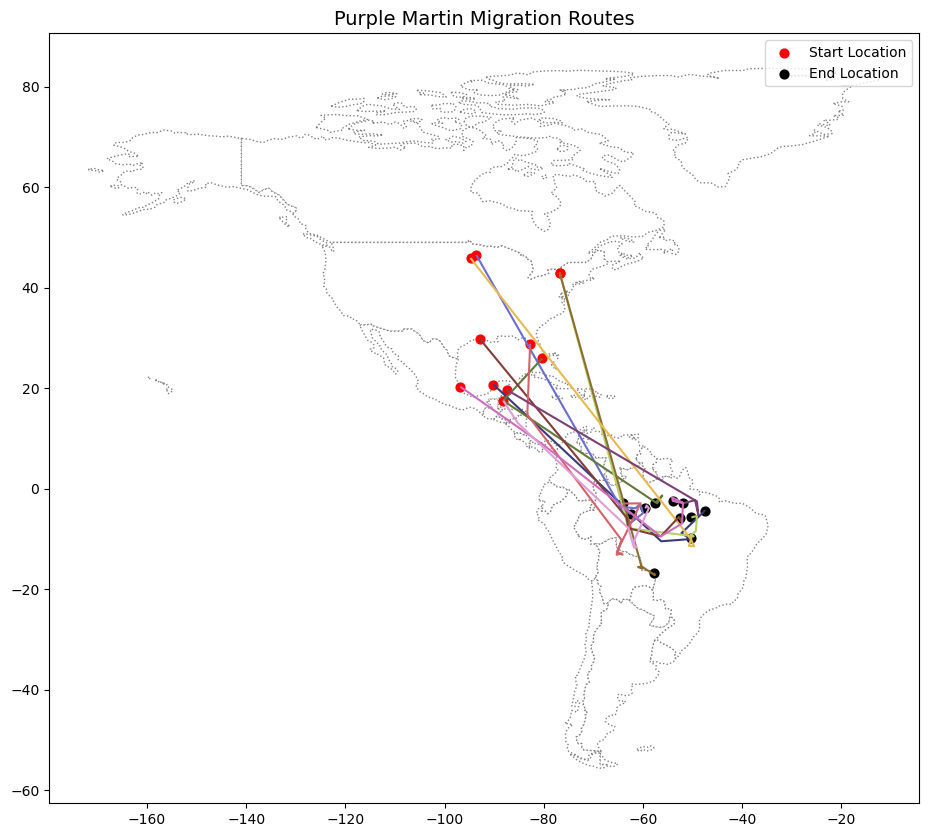

In [10]:
ax = americas.plot(
    figsize=(12,10),
    color='white',
    edgecolor='gray',
    linestyle=':'
)

start_gdf.plot(
    ax=ax,
    color='red',
    markersize=40,
    label='Start Location'
)

path_gdf.plot(
    ax=ax,
    cmap='tab20b',
    linewidth=1.5
)

end_gdf.plot(
    ax=ax,
    color='black',
    markersize=40,
    label='End Location'
)

ax.set_title("Purple Martin Migration Routes", fontsize=14)
plt.legend()

In [11]:
fig = ax.get_figure()

fig.savefig(
    r"C:\Data Analytics\GeoSpatialAnalysis\Images\CaseStudy2\migration_routes.png",
    bbox_inches='tight',
    dpi=300
)

## Protected Areas in South America

To understand whether Purple Martin migration routes overlap with conservation regions, protected areas in South America were analyzed and visualized.

In [12]:
protected_areas=gpd.read_file("C:\Data Analytics\GeoSpatialAnalysis\Data\SAPA_Aug2019-shapefile\SAPA_Aug2019-shapefile\SAPA_Aug2019-shapefile-polygons.shp")

In [13]:
south_america=americas.loc[americas['CONTINENT']=='South America']

## Visualizing Protected Areas in South America

<Axes: >

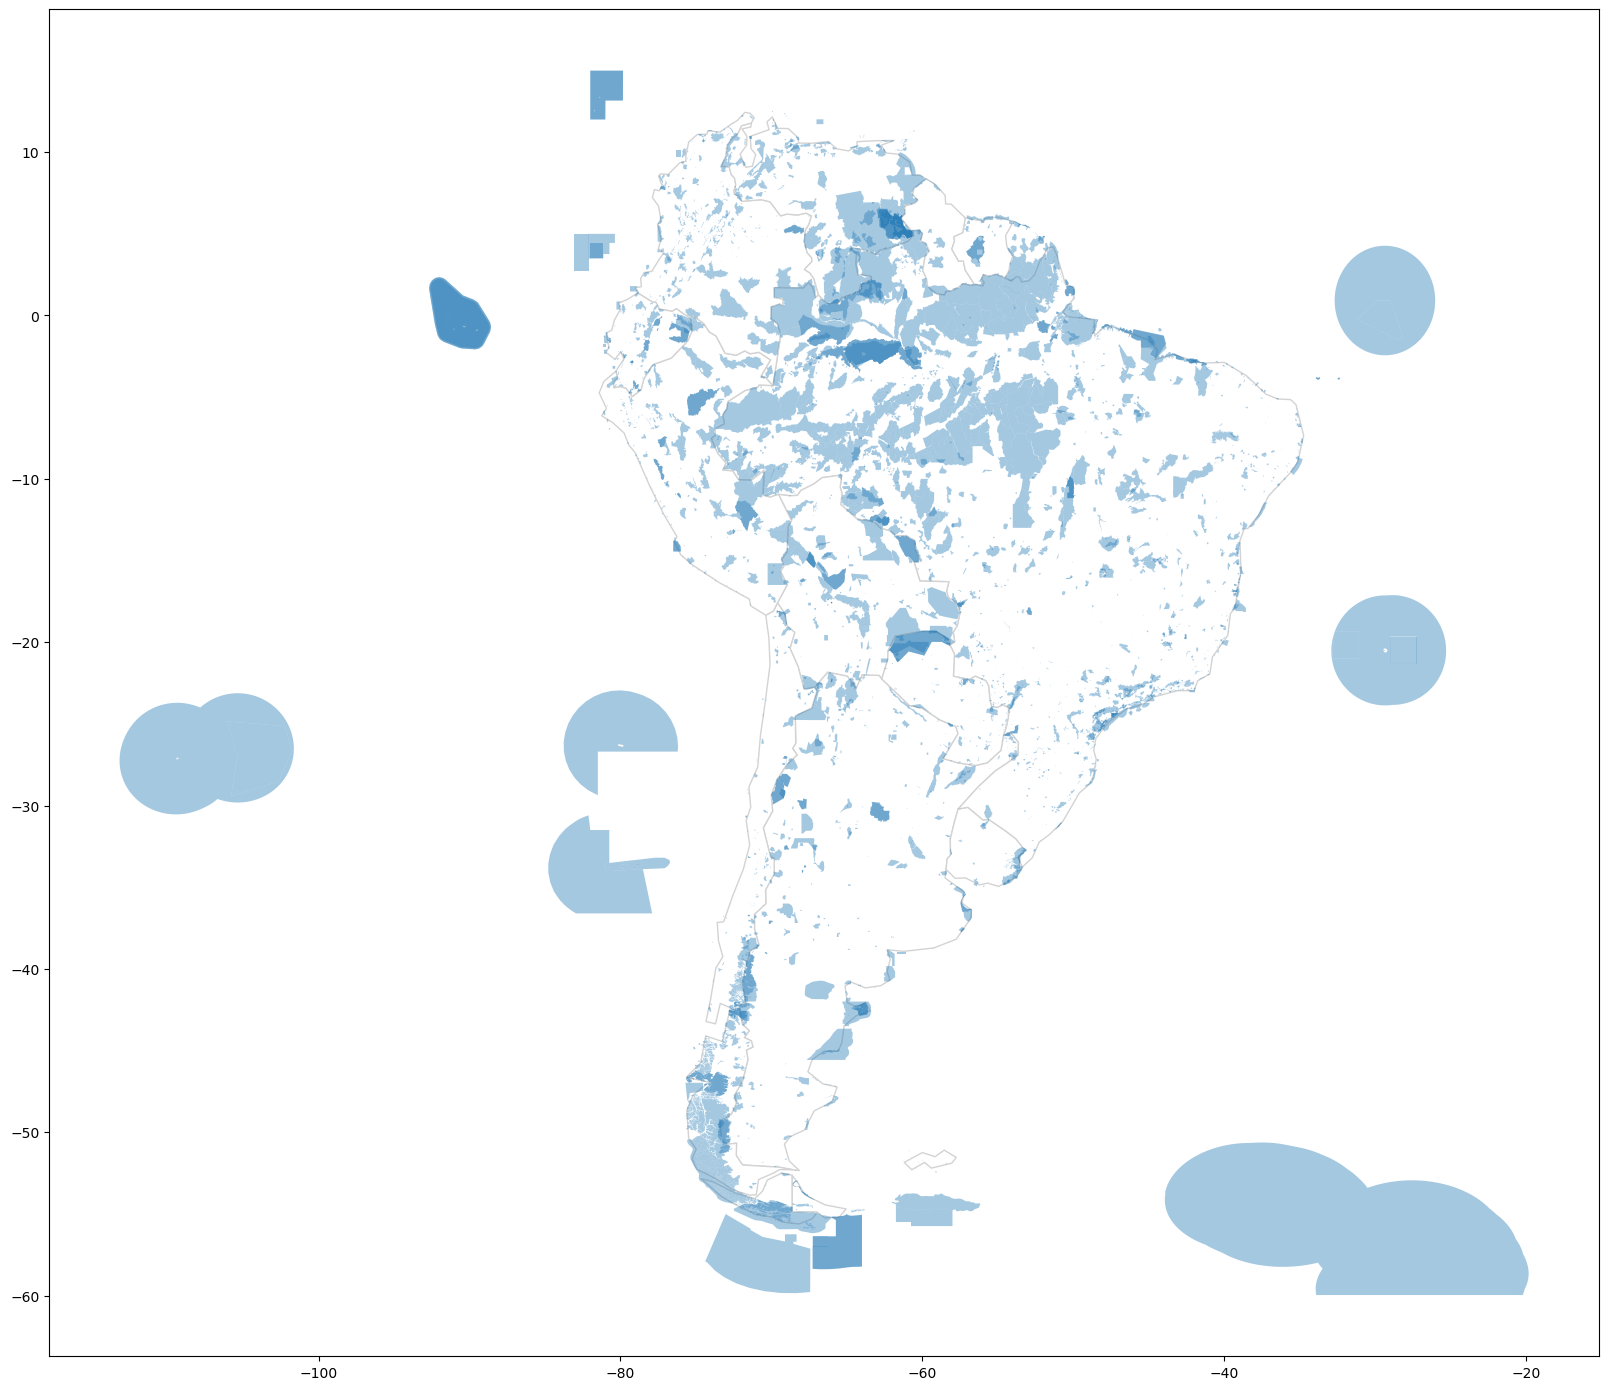

In [14]:
ax=south_america.plot(figsize=(20,20),edgecolor='lightgrey',color='white')
protected_areas.plot(ax=ax,alpha=0.4)

In [15]:
fig = ax.get_figure()

fig.savefig(
    r"C:\Data Analytics\GeoSpatialAnalysis\Images\CaseStudy2\protected_areas_south_america.png",
    dpi=300,
    bbox_inches="tight"
)

## Protected Area Coverage Analysis

In [16]:
P_Area = (protected_areas['REP_AREA'] - protected_areas['REP_M_AREA']).sum()
print("South America has {} square kilometers of protected areas.".format(P_Area))

South America has 5396761.911688372 square kilometers of protected areas.


In [17]:
south_america = south_america.to_crs(epsg=3035)
totalArea=south_america.area.sum()/10**6
print(totalArea)

17759005.81506123


In [18]:
# Calculate the percentage of protected land in South America
percentage_protected = P_Area/totalArea
print('Approximately {}% of South America is protected.'.format(round(percentage_protected*100,2)))

Approximately 30.39% of South America is protected.


## Bird Locations and Protected Areas


Text(0.5, 1.0, 'Bird Locations and Protected Areas in South America')

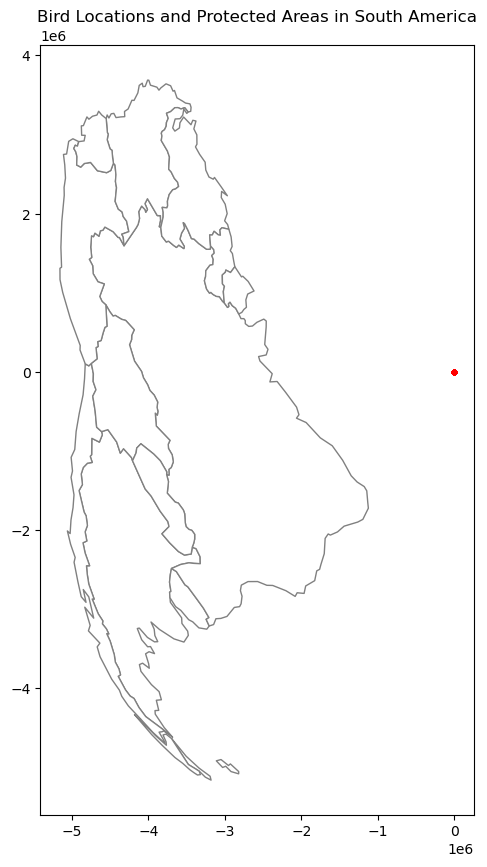

In [19]:
ax = south_america.plot(
    figsize=(12,10),
    color='white',
    edgecolor='gray'
)

protected_areas.plot(
    ax=ax,
    color='lightgreen',
    alpha=0.5
)

birds.plot(
    ax=ax,
    color='red',
    markersize=8
)

plt.title("Bird Locations and Protected Areas in South America")

In [20]:
fig=ax.get_figure()
fig.savefig(
    r"C:\Data Analytics\GeoSpatialAnalysis\Images\CaseStudy2\birds_vs_protected_areas.png",
    dpi=300,
    bbox_inches="tight"
)

# Conclusion

- Loaded and analyzed GPS tracking data for 11 Purple Martin birds using GeoPandas.
- Converted latitude and longitude coordinates into Point geometries and stored them in a GeoDataFrame.
- Applied the EPSG:4326 Coordinate Reference System (CRS) to accurately represent geographic locations.
- Created migration routes using LineString geometries to visualize bird movement across North and South America.
- Identified the starting and ending locations of each bird's migration journey.
- Visualized protected conservation areas in South America and calculated the total protected land area.
- Compared bird locations with protected regions to understand the relationship between migration patterns and conservation areas.
- Gained practical experience with GeoDataFrames, CRS transformations, geospatial visualization, and spatial analysis using Python and GeoPandas.